In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


In [2]:
# Simulate daily returns for 4 assets over 252 trading days
n_assets = 4
n_days = 252

mean_returns = np.array([0.0005, 0.0004, 0.0003, 0.0002])  # average daily returns
cov_matrix = np.array([
    [0.0001, 0.00002, 0.000015, 0.00001],
    [0.00002, 0.0001, 0.000025, 0.000015],
    [0.000015, 0.000025, 0.0001, 0.00002],
    [0.00001, 0.000015, 0.00002, 0.0001]
])

returns = np.random.multivariate_normal(mean_returns, cov_matrix, size=n_days)


In [3]:
def calculate_cvar(portfolio_returns, alpha=0.95):
    var_threshold = np.percentile(portfolio_returns, (1 - alpha) * 100)
    cvar = portfolio_returns[portfolio_returns <= var_threshold].mean()
    return -cvar  # we negate to represent risk


In [4]:
n_samples = 10000
best_weights = None
min_cvar = float('inf')

for _ in range(n_samples):
    weights = np.random.dirichlet(np.ones(n_assets))  # ensure weights sum to 1
    portfolio_returns = returns @ weights
    cvar = calculate_cvar(portfolio_returns)
    if cvar < min_cvar:
        min_cvar = cvar
        best_weights = weights


In [5]:
print("Optimal Portfolio Weights (minimizing CVaR):")
for i, w in enumerate(best_weights):
    print(f"Asset {i+1}: {w:.4f}")


Optimal Portfolio Weights (minimizing CVaR):
Asset 1: 0.3668
Asset 2: 0.1682
Asset 3: 0.1896
Asset 4: 0.2754


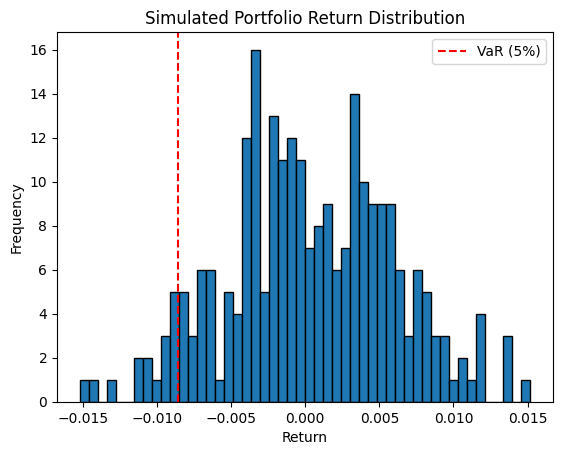

In [6]:
optimal_returns = returns @ best_weights

plt.hist(optimal_returns, bins=50, edgecolor='black')
plt.axvline(np.percentile(optimal_returns, 5), color='red', linestyle='dashed', label='VaR (5%)')
plt.title("Simulated Portfolio Return Distribution")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.legend()
plt.show()
